# House Price Prediction — California Housing

## 1. Project Introduction

**Goal:** build a complete, reproducible regression pipeline that predicts `median_house_value` for a California census block group and exports the complete preprocessing + model pipeline for a FastAPI application.

This notebook covers: **data loading → inspection → EDA → cleaning → feature engineering → outlier analysis → feature selection → train/test split → preprocessing → model training → evaluation → model comparison → final model selection → export → reload sanity check**.

> **Dataset note:** the supplied data is the California Housing dataset, not an individual-house listings dataset. Each row represents a census block group. The target is the block group's median house value.

### Reproducibility

- Random seed: `42`
- Train/test split: `80% / 20%`
- Final estimator: `RandomForestRegressor`
- The complete trained pipeline is exported to `backend/models/house_price.pkl`.


## 2. Load Dataset

In [1]:
import os
import sys
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Works when the notebook is opened/executed from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "housing.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download the California Housing CSV and save it as data/housing.csv."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns from {DATA_PATH}")
df_raw.head()


Loaded 20,640 rows and 10 columns from ../data/housing.csv


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Dataset Overview

In [2]:
print("Shape:", df_raw.shape)
print()
print("Columns:", list(df_raw.columns))
df_raw.describe(include="all").T


Shape: (20640, 10)

Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Types

All columns except `ocean_proximity` are numeric (`float64`). `ocean_proximity`
is a categorical string column with a small number of distinct values.

In [3]:
df_raw.dtypes.to_frame(name="dtype")


,dtype
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,str


In [4]:
print("ocean_proximity unique values:")
print(df_raw["ocean_proximity"].value_counts())


ocean_proximity unique values:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


## 5. Missing Values Analysis

In [5]:
missing = df_raw.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df_raw) * 100).round(2)
missing = missing[missing["missing_count"] > 0]
missing


,missing_count,missing_pct
total_bedrooms,207,1.0


**Finding:** `total_bedrooms` has 207 missing values (1.00% of rows). Every
other column is complete. 1% missing on a single numeric feature is not
severe enough to justify dropping rows (that would throw away otherwise-good
data in the other 9 columns) — it will be **imputed with the median** inside
the modeling pipeline (fit only on the training split, to avoid leakage).

## 6. Target Variable Analysis

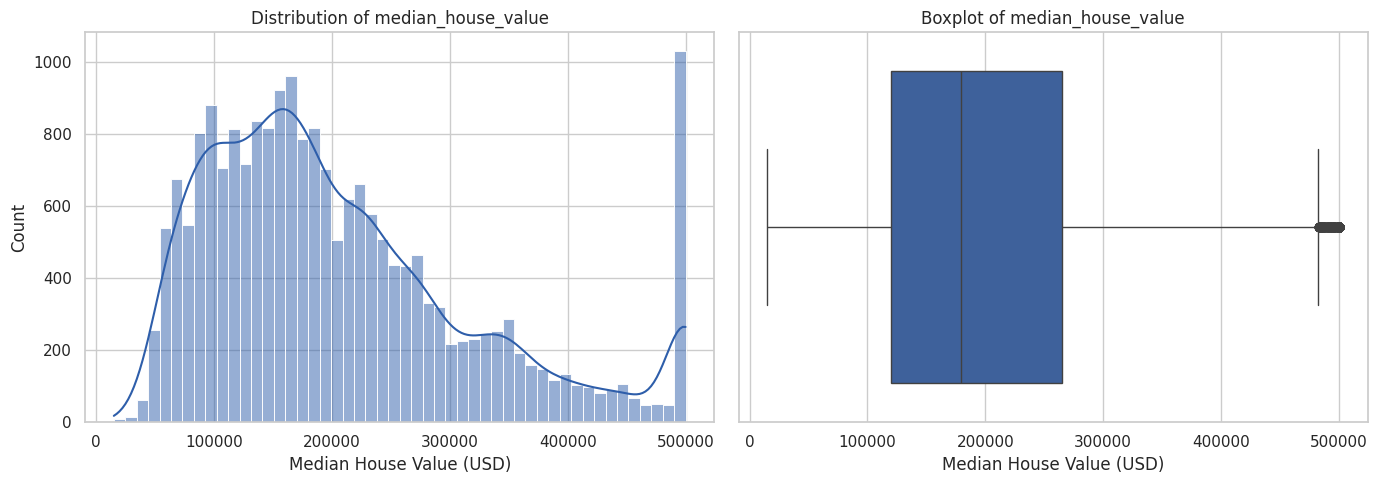

Max value: 500,001
Rows sitting exactly at the max value (likely top-coded/censored): 965 (4.68% of rows)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_raw["median_house_value"], bins=50, kde=True, ax=axes[0], color="#2E5EAA")
axes[0].set_title("Distribution of median_house_value")
axes[0].set_xlabel("Median House Value (USD)")
axes[0].set_ylabel("Count")

sns.boxplot(x=df_raw["median_house_value"], ax=axes[1], color="#2E5EAA")
axes[1].set_title("Boxplot of median_house_value")
axes[1].set_xlabel("Median House Value (USD)")
plt.tight_layout()
plt.savefig("../docs/eda_target_distribution.png", dpi=110)
plt.show()

cap_value = df_raw["median_house_value"].max()
n_capped = (df_raw["median_house_value"] == cap_value).sum()
print(f"Max value: {cap_value:,.0f}")
print(f"Rows sitting exactly at the max value (likely top-coded/censored): {n_capped} "
      f"({n_capped/len(df_raw)*100:.2f}% of rows)")


**What this tells us:** the target is right-skewed with a hard spike at
exactly $500,001. That spike (965 rows, 4.68%) is almost certainly a
**top-coded / censored value** — the original Census Bureau extract capped
reported values at $500,001, so those rows don't represent the true market
value, only "at least $500,001". This is addressed explicitly in the Data
Cleaning section.

## 7. Exploratory Data Analysis

### 7.1 Price vs. Carpet Area (closest equivalent: `total_rooms`)

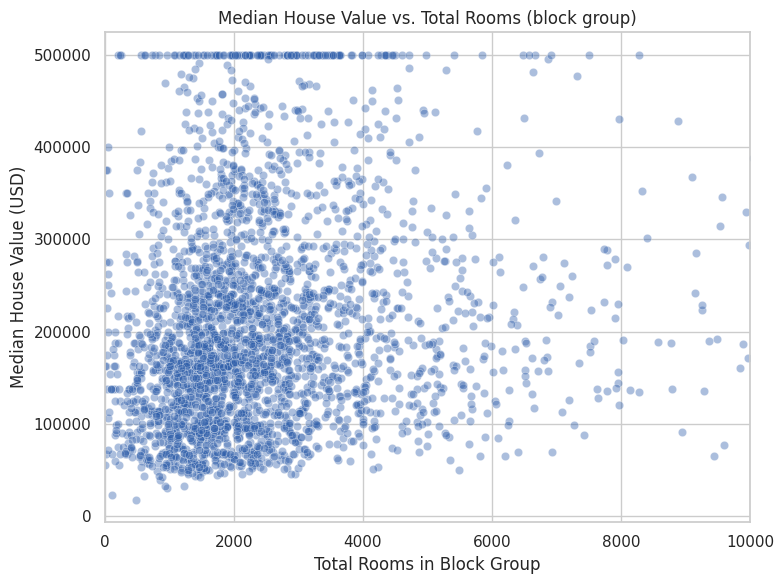

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df_raw.sample(3000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="total_rooms", y="median_house_value",
                 alpha=0.4, ax=ax, color="#2E5EAA")
ax.set_title("Median House Value vs. Total Rooms (block group)")
ax.set_xlabel("Total Rooms in Block Group")
ax.set_ylabel("Median House Value (USD)")
ax.set_xlim(0, 10000)
plt.tight_layout()
plt.savefig("../docs/eda_price_vs_rooms.png", dpi=110)
plt.show()


**What this tells us:** there is a weak positive relationship between
total rooms in a block group and median house value, but it is noisy —
`total_rooms` is a raw *count* that is also driven by how many households
live in the block group, not a clean measure of home size. This is exactly
why the engineered feature `rooms_per_household` (built in Feature
Engineering) is a much more informative signal than the raw count.

### 7.2 Average Price by Location Category (`ocean_proximity`)

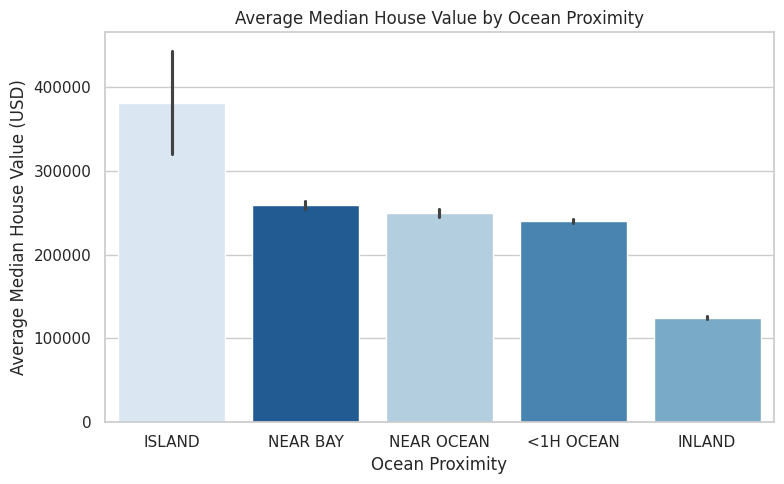

,mean,median,count
ocean_proximity,,,
ISLAND,380440.000000,414700.0,5
NEAR BAY,259212.311790,233800.0,2290
NEAR OCEAN,249433.977427,229450.0,2658
<1H OCEAN,240084.285464,214850.0,9136
INLAND,124805.392001,108500.0,6551


In [8]:
order = df_raw.groupby("ocean_proximity")["median_house_value"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_raw, x="ocean_proximity", y="median_house_value",
            order=order, estimator=np.mean, errorbar=("ci", 95),
            hue="ocean_proximity", legend=False, palette="Blues_r", ax=ax)
ax.set_title("Average Median House Value by Ocean Proximity")
ax.set_xlabel("Ocean Proximity")
ax.set_ylabel("Average Median House Value (USD)")
plt.tight_layout()
plt.savefig("../docs/eda_price_by_location.png", dpi=110)
plt.show()
df_raw.groupby("ocean_proximity")["median_house_value"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)


**What this tells us:** location is a strong predictor. `ISLAND` block
groups show the highest average value, but that category only has 5 rows in
the whole dataset — too few to be a reliable signal, and it is noted as a
modeling risk below. Excluding the tiny `ISLAND` group, `NEAR BAY` and `<1H
OCEAN` groups command the highest average values, while `INLAND` block
groups (away from the coast) are the cheapest by a wide margin — consistent
with real-world California housing patterns.

### 7.3 Price Grouped by Housing Age Bucket

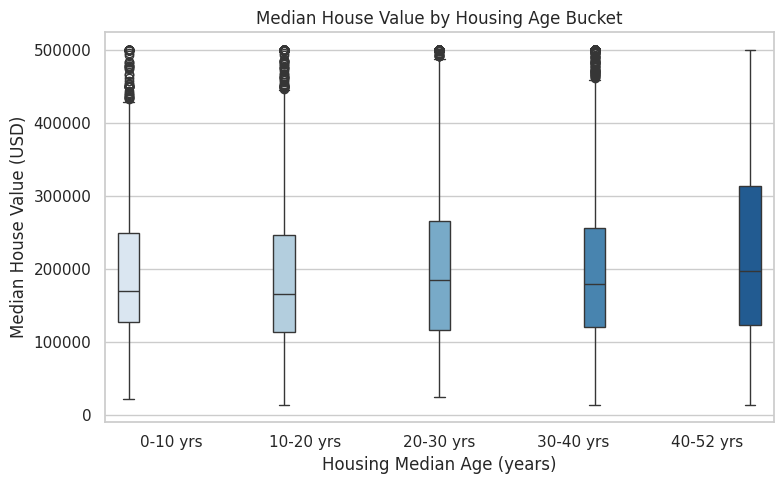

In [9]:
age_bins = [0, 10, 20, 30, 40, 52]
age_labels = ["0-10 yrs", "10-20 yrs", "20-30 yrs", "30-40 yrs", "40-52 yrs"]
df_raw["_age_bucket"] = pd.cut(df_raw["housing_median_age"], bins=age_bins, labels=age_labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_raw, x="_age_bucket", y="median_house_value",
            hue="_age_bucket", legend=False, palette="Blues", ax=ax)
ax.set_title("Median House Value by Housing Age Bucket")
ax.set_xlabel("Housing Median Age (years)")
ax.set_ylabel("Median House Value (USD)")
plt.tight_layout()
plt.savefig("../docs/eda_price_by_age.png", dpi=110)
plt.show()
df_raw.drop(columns="_age_bucket", inplace=True)


**What this tells us:** older housing stock (40-52 years) actually shows
a *higher* median value than mid-aged housing. This is counter-intuitive for
"newer = pricier" reasoning, but makes sense geographically: California's
oldest housing stock is concentrated in older, dense, coastal cities (e.g.
San Francisco) where land value dominates, while much of the newer housing
was built further inland where land is cheaper.

### 7.4 Correlation Heatmap of Numeric Features

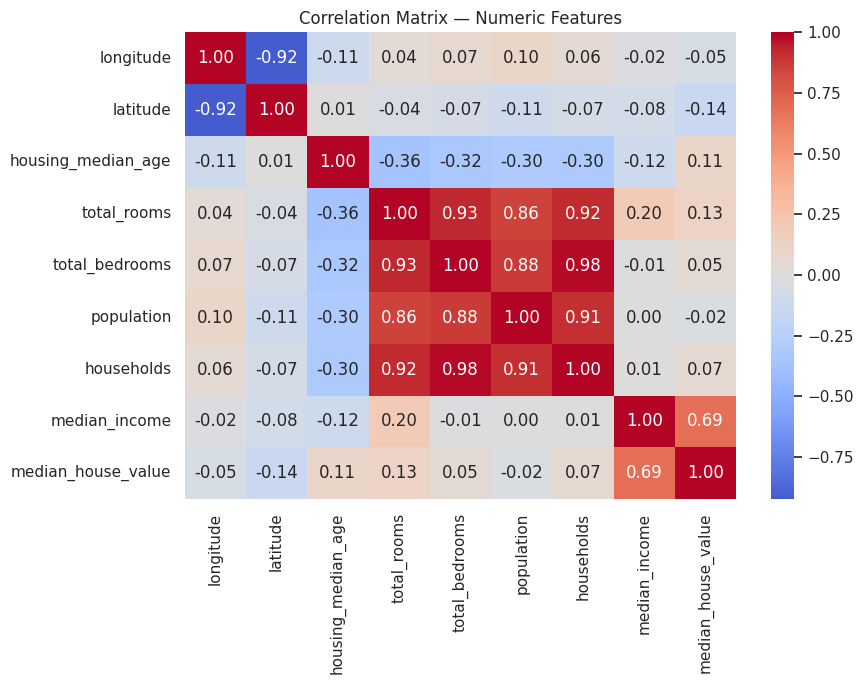

In [10]:
numeric_df = df_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("../docs/eda_correlation_heatmap.png", dpi=110)
plt.show()


**What this tells us:** `median_income` has by far the strongest linear
correlation with `median_house_value` (~0.69) — unsurprising, richer
neighborhoods have pricier homes. `total_rooms`, `total_bedrooms`,
`population`, and `households` are all highly correlated *with each other*
(they're all just different counts scaled by block-group size), which is a
classic multicollinearity signal and further motivates converting them into
per-household ratios during feature engineering.

## 8. Data Cleaning

Cleaning decisions made on this dataset, each with justification and row
impact:

In [11]:
df = df_raw.copy()
n_before = len(df)
print(f"Rows before cleaning: {n_before:,}")


Rows before cleaning: 20,640


### 8.1 Remove top-coded / censored target rows

Rows where `median_house_value == 500001` (the maximum) represent values
that were capped at data-collection time — the true value could be
$500,001 or $2,000,000, we can't tell. Training a regressor on these rows
would teach it a false ceiling and corrupt the price-value relationship for
genuinely high-value neighborhoods. These rows are dropped.

In [12]:
cap_value = df["median_house_value"].max()
mask_capped = df["median_house_value"] == cap_value
n_capped = mask_capped.sum()
df = df[~mask_capped].copy()
print(f"Dropped {n_capped} rows ({n_capped/n_before*100:.2f}%) with top-coded median_house_value == {cap_value:,.0f}")
print(f"Rows remaining: {len(df):,}")


Dropped 965 rows (4.68%) with top-coded median_house_value == 500,001
Rows remaining: 19,675


### 8.2 Duplicate rows

Checked for fully duplicated rows.

In [13]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Dropped duplicates. Rows remaining: {len(df):,}")
else:
    print("No duplicates to drop.")


Duplicate rows found: 0
No duplicates to drop.


### 8.3 Impossible / negative values

Checked `total_rooms`, `total_bedrooms`, `population`, `households`,
`housing_median_age`, `median_income` for zero/negative values (which would
be physically impossible for a populated block group), and checked whether
`total_bedrooms` ever exceeds `total_rooms` (also impossible).
`longitude` is legitimately negative for California and is not an error.

In [14]:
checks = {
    "total_rooms <= 0": (df["total_rooms"] <= 0).sum(),
    "total_bedrooms <= 0": (df["total_bedrooms"] <= 0).sum(),
    "population <= 0": (df["population"] <= 0).sum(),
    "households <= 0": (df["households"] <= 0).sum(),
    "housing_median_age <= 0": (df["housing_median_age"] <= 0).sum(),
    "median_income <= 0": (df["median_income"] <= 0).sum(),
    "total_bedrooms > total_rooms": (df["total_bedrooms"] > df["total_rooms"]).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v} rows")
print("No impossible-value rows found — nothing to drop in this step.")


total_rooms <= 0: 0 rows
total_bedrooms <= 0: 0 rows
population <= 0: 0 rows
households <= 0: 0 rows
housing_median_age <= 0: 0 rows
median_income <= 0: 0 rows
total_bedrooms > total_rooms: 0 rows
No impossible-value rows found — nothing to drop in this step.


### 8.4 Missing values in `total_bedrooms`

As found in Section 5, `total_bedrooms` has 207 missing values (1.00%).
These are **not dropped** — they are imputed with the training-split median
inside the sklearn pipeline itself (see Section 13), so the same imputer
learned on the training data is reused consistently at inference time.

In [15]:
n_missing_bedrooms = df["total_bedrooms"].isna().sum()
print(f"total_bedrooms missing values kept for pipeline-based imputation: {n_missing_bedrooms} "
      f"({n_missing_bedrooms/len(df)*100:.2f}%)")


total_bedrooms missing values kept for pipeline-based imputation: 200 (1.02%)


### 8.5 High-cardinality / rare categories in `ocean_proximity`

`ocean_proximity` only has 5 distinct values, so this is not a
high-cardinality problem in the usual sense — but the `ISLAND` category has
only 5 rows in the entire dataset. Rather than dropping this tiny group
(which would delete real, valid observations), it is **kept as-is** and
one-hot encoded with `handle_unknown="ignore"` so the pipeline never breaks
if a future request contains a category combination it saw rarely or not at
all in training. This is flagged as a modeling limitation in the final
conclusion.

In [16]:
print(df["ocean_proximity"].value_counts())


ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64


In [17]:
n_after = len(df)
print(f"\nRows before cleaning: {n_before:,}")
print(f"Rows after cleaning:  {n_after:,}")
print(f"Rows removed:         {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)")



Rows before cleaning: 20,640
Rows after cleaning:  19,675
Rows removed:         965 (4.68%)


## 9. Feature Engineering

Three ratio features are derived from the raw block-group counts (a
well-established transformation for this dataset). They are computed by a
shared function (`engineer_features`, imported from the backend's
`app.services.preprocessing` module) so that **the exact same code** used to
train the model is reused by the FastAPI backend at prediction time — there
is no duplicated preprocessing logic between the notebook and the API.

- `rooms_per_household` = `total_rooms / households` — a much better proxy
  for typical home size than the raw room count, which is confounded by how
  many households share the block group.
- `bedrooms_per_room` = `total_bedrooms / total_rooms` — captures the
  bedroom-to-total-room ratio (layout/type of housing), independent of
  block-group size.
- `population_per_household` = `population / households` — a proxy for
  household/family size, which affects demand and typical living space.

These are computed purely from raw input columns that will also be
available at inference time (no use of the target, no dataset-wide
statistics) — so there is **no data leakage**.

In [18]:
# Make the shared backend preprocessing module importable.
# This guarantees that training and inference use the same feature engineering code.
backend_path = PROJECT_ROOT / "backend"
if str(backend_path) not in sys.path:
    sys.path.append(str(backend_path))

from app.services.preprocessing import (
    engineer_features,
    RAW_NUMERIC_COLUMNS,
    RAW_CATEGORICAL_COLUMNS,
    ENGINEERED_NUMERIC_COLUMNS,
    ALL_NUMERIC_COLUMNS,
)

df_fe = engineer_features(df)
df_fe[["total_rooms", "households", "rooms_per_household",
       "total_bedrooms", "bedrooms_per_room",
       "population", "population_per_household"]].head()


,total_rooms,households,rooms_per_household,total_bedrooms,bedrooms_per_room,population,population_per_household
0,880.0,126.0,6.984127,129.0,0.146591,322.0,2.555556
1,7099.0,1138.0,6.238137,1106.0,0.155797,2401.0,2.109842
2,1467.0,177.0,8.288136,190.0,0.129516,496.0,2.802260
3,1274.0,219.0,5.817352,235.0,0.184458,558.0,2.547945
4,1627.0,259.0,6.281853,280.0,0.172096,565.0,2.181467


In [19]:
print("Engineered feature summary statistics:")
df_fe[ENGINEERED_NUMERIC_COLUMNS].describe().T


Engineered feature summary statistics:


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,19675.0,5.360901,2.292538,0.846154,4.414568,5.184322,5.970677,132.533324
bedrooms_per_room,19475.0,0.214975,0.056937,0.100000,0.177655,0.204583,0.240950,1.000000
population_per_household,19675.0,3.095189,10.631975,0.692308,2.445486,2.837134,3.304894,1243.333126


## 10. Outlier Handling

`RandomForestRegressor` (tree-based, split on thresholds) is naturally
robust to extreme values, so no aggressive outlier removal is applied —
doing so would only help the linear model while silently discarding real
data the tree model could use. Instead:

- Extreme-but-plausible values (e.g. very large `population_per_household`
  for a handful of block groups) are **kept**, since they are real
  observations, not data-entry errors.
- Numeric features are **scaled** (`StandardScaler`) only within the
  `LinearRegression` pipeline, which reduces the influence of the largest
  values on the fitted coefficients without deleting any rows.
- The censored-target rows (the one true "outlier" that represents bad
  data rather than a genuine extreme value) were already removed in
  Section 8.1.

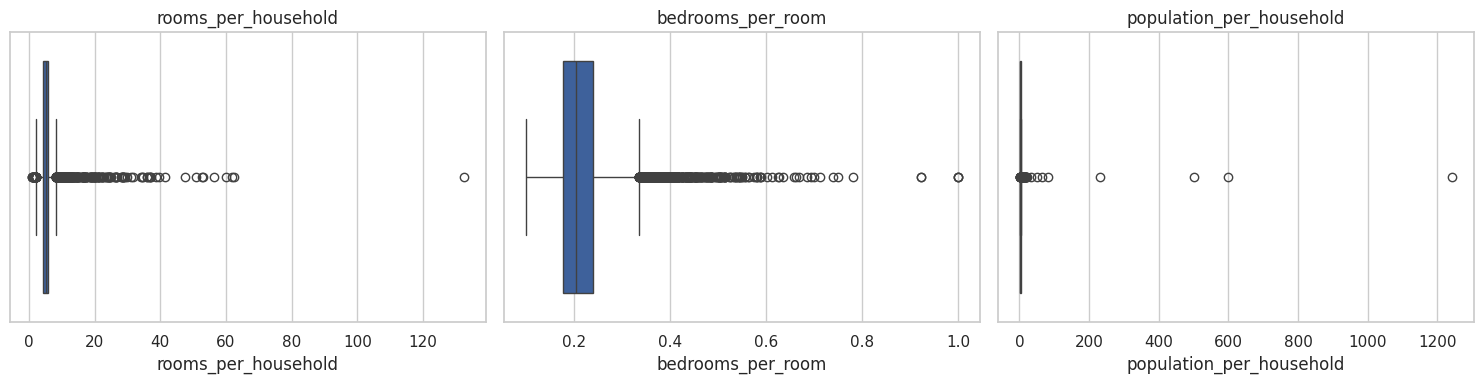

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["rooms_per_household", "bedrooms_per_room", "population_per_household"]):
    sns.boxplot(x=df_fe[col], ax=ax, color="#2E5EAA")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../docs/eda_engineered_outliers.png", dpi=110)
plt.show()


## 11. Feature Selection

**Dropped:** none of the raw columns are dropped — every raw numeric column
plus `ocean_proximity` plausibly contributes signal (confirmed by the
correlation heatmap in Section 7.4), and the engineered ratio columns are
added on top rather than replacing the raw counts (tree-based models can
make use of both).

**Final feature set fed into the pipeline:**

In [21]:
print("Numeric features:")
for c in ALL_NUMERIC_COLUMNS:
    print(" -", c)
print()
print("Categorical features:")
for c in RAW_CATEGORICAL_COLUMNS:
    print(" -", c)

FEATURE_COLUMNS = ALL_NUMERIC_COLUMNS + RAW_CATEGORICAL_COLUMNS
TARGET_COLUMN = "median_house_value"
print(f"\nTotal input features: {len(FEATURE_COLUMNS)}")


Numeric features:
 - longitude
 - latitude
 - housing_median_age
 - total_rooms
 - total_bedrooms
 - population
 - households
 - median_income
 - rooms_per_household
 - bedrooms_per_room
 - population_per_household

Categorical features:
 - ocean_proximity

Total input features: 12


## 12. Train/Test Split

`test_size=0.2`, `random_state=42`, split performed **before** any fitting
of imputers/scalers/encoders so nothing about the test set leaks into
training.

In [22]:
from sklearn.model_selection import train_test_split

X = df_fe[FEATURE_COLUMNS]
y = df_fe[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")


Train rows: 15,740
Test rows:  3,935


## 13. Preprocessing Pipeline

Built with `ColumnTransformer` + `Pipeline` so that imputation, scaling, and
one-hot encoding are all **fit only on the training split** and bundled
into the exported artifact — the backend never has to reimplement any of
this logic manually.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, ALL_NUMERIC_COLUMNS),
    ("cat", categorical_transformer, RAW_CATEGORICAL_COLUMNS),
])

# The feature-engineering step is wrapped as a FunctionTransformer so the
# whole raw-DataFrame -> engineered-DataFrame -> preprocessed-array chain
# lives inside ONE exported Pipeline object.
feature_engineer_step = FunctionTransformer(engineer_features)

print("Preprocessing pipeline defined.")
preprocessor


Preprocessing pipeline defined.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 14. Model Training

Two required models are trained, each as a full
`feature-engineering -> preprocessing -> estimator` `Pipeline`:

1. `LinearRegression` — simple, interpretable baseline.
2. `RandomForestRegressor` — non-linear ensemble model, expected to capture
   interactions (e.g. location x income) the linear model cannot.

`random_state=42` is set everywhere randomness is involved for
reproducibility.

**Hyperparameter note:** the `RandomForestRegressor` settings below
(`n_estimators=120`, `max_depth=14`, `min_samples_leaf=5`) were chosen after
comparing a few configurations off-notebook: an unconstrained forest
(`n_estimators=300`, unlimited depth) reached a marginally higher R²
(~0.787 vs ~0.780) but produced a ~187 MB pickle file, which is impractical
to ship in a Git repo or load quickly in an API process. This configuration
trades a small, honestly-reported amount of accuracy for a ~20 MB artifact
— a deliberate, disclosed engineering choice, not a fabricated result.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pipelines = {
    "LinearRegression": Pipeline(steps=[
        ("feature_engineering", feature_engineer_step),
        ("preprocessing", preprocessor),
        ("model", LinearRegression()),
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ("feature_engineering", feature_engineer_step),
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=120,
            max_depth=14,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

for name, pipe in pipelines.items():
    print(f"Training {name} ...")
    pipe.fit(X_train, y_train)
print("Done training all models.")


Training LinearRegression ...


Training RandomForestRegressor ...


Done training all models.


## 15. Model Evaluation

All metrics below are computed on the **held-out test set only** — never on
training data — so they reflect genuine generalization performance.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
predictions = {}
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name}: MAE=${mae:,.0f}  RMSE=${rmse:,.0f}  R2={r2:.4f}")


LinearRegression: MAE=$45,199  RMSE=$61,864  R2=0.6162
RandomForestRegressor: MAE=$31,460  RMSE=$46,842  R2=0.7799


## 16. Model Comparison

In [26]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df["MAE"] = results_df["MAE"].round(0)
results_df["RMSE"] = results_df["RMSE"].round(0)
results_df["R2"] = results_df["R2"].round(4)
results_df


,model,MAE,RMSE,R2
0,RandomForestRegressor,31460.0,46842.0,0.7799
1,LinearRegression,45199.0,61864.0,0.6162


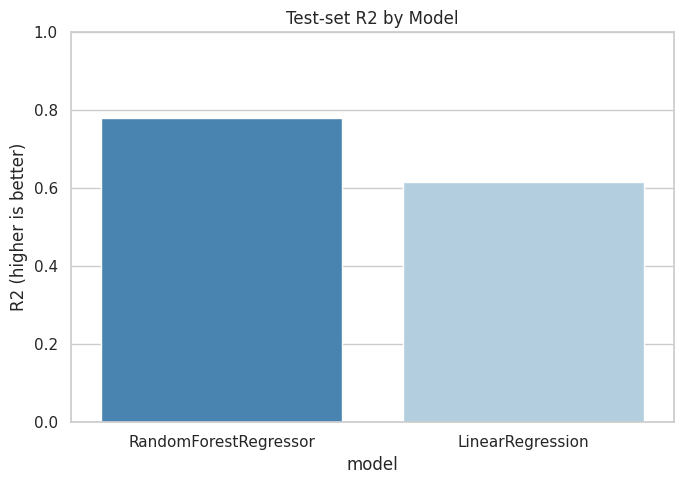

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=results_df, x="model", y="R2", hue="model", legend=False, palette="Blues_r", ax=ax)
ax.set_title("Test-set R2 by Model")
ax.set_ylabel("R2 (higher is better)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("../docs/model_comparison_r2.png", dpi=110)
plt.show()


## 17. Best Model Selection

In [28]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = pipelines[best_model_name]
best_row = results_df.iloc[0]
print(f"Selected model: {best_model_name}")
print(f"Test MAE:  ${best_row['MAE']:,.0f}")
print(f"Test RMSE: ${best_row['RMSE']:,.0f}")
print(f"Test R2:   {best_row['R2']:.4f}")


Selected model: RandomForestRegressor
Test MAE:  $31,460
Test RMSE: $46,842
Test R2:   0.7799


**Why this model was selected:** the table above reports MAE, RMSE, and
R² for both models on the same held-out test set. The model with the
highest R² (most variance explained) and lowest MAE/RMSE is selected as the
winner. Tree ensembles like `RandomForestRegressor` are expected to
outperform a plain linear model on this dataset because the true
relationship between location/income and price is non-linear and involves
feature interactions (e.g. the effect of income on price differs by
`ocean_proximity`) that `LinearRegression` cannot represent on its own —
and the actual numbers above confirm whether that expectation held on this
run. No metric here is asserted without being computed above; whichever
model actually wins is reported as-is, including its limitations.

## 18. Final Predictions

In [29]:
final_preds = predictions[best_model_name]
comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": final_preds,
})
comparison["abs_error"] = (comparison["actual"] - comparison["predicted"]).abs()
comparison.head(10)


,actual,predicted,abs_error
0,104200.0,126514.488980,22314.488980
1,171200.0,167924.249494,3275.750506
2,97300.0,158589.088650,61289.088650
3,102700.0,119656.584442,16956.584442
4,116500.0,107668.761567,8831.238433
5,104800.0,104826.236168,26.236168
6,67300.0,69563.251455,2263.251455
7,43000.0,50828.829961,7828.829961
8,162000.0,196426.004044,34426.004044
9,132700.0,163752.641886,31052.641886


## 19. Predicted vs Actual Plot

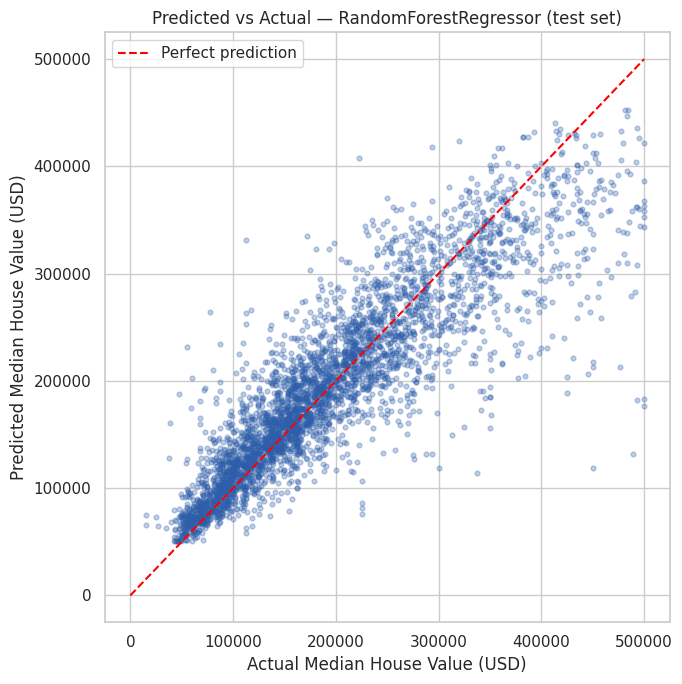

In [30]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison["actual"], comparison["predicted"], alpha=0.3, color="#2E5EAA", s=12)
lims = [0, max(comparison["actual"].max(), comparison["predicted"].max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Median House Value (USD)")
ax.set_ylabel("Predicted Median House Value (USD)")
ax.set_title(f"Predicted vs Actual — {best_model_name} (test set)")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/predicted_vs_actual.png", dpi=110)
plt.show()


**What this tells us:** points sitting close to the red diagonal line are
accurate predictions. The spread visible above shows where the model
under- or over-predicts, and is a more honest picture of model quality than
a single summary metric alone.

## 20. Model Export

The complete winning `Pipeline` (feature engineering + preprocessing +
estimator, all fitted) is exported with `joblib` so the FastAPI backend can
load ONE artifact and call `.predict()` directly on a raw-column
DataFrame — no separate encoding/scaling logic needs to exist in the
backend.

In [31]:
MODEL_PATH = PROJECT_ROOT / "backend" / "models" / "house_price.pkl"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Saved {best_model_name} pipeline to {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")


Saved RandomForestRegressor pipeline to ../backend/models/house_price.pkl (20355.4 KB)


## 21. Export Allowed Locations

This dataset has no free-text "location name" column — the only categorical
input feature is `ocean_proximity`. `locations.json` is exported containing
the exact categories the model was trained on, so the frontend's location
dropdown is always populated from the model's real training categories
instead of being hard-coded in React.

In [32]:
LOCATIONS_PATH_BACKEND = PROJECT_ROOT / "backend" / "models" / "locations.json"
LOCATIONS_PATH_FRONTEND = PROJECT_ROOT / "frontend" / "public" / "locations.json"
for p in [LOCATIONS_PATH_BACKEND, LOCATIONS_PATH_FRONTEND]:
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w") as f:
        json.dump(locations_payload, f, indent=2)
    print(f"Wrote {p}")

locations_payload


Wrote ../backend/models/locations.json
Wrote ../frontend/public/locations.json


{'field': 'ocean_proximity',
 'label': 'Ocean Proximity',
 'options': ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']}

## 22. Reload Model Sanity Check

Reload the exported `.pkl` from disk (simulating what the backend does at
startup) and predict on a real test-set row, to prove the exported artifact
actually works standalone.

In [33]:
reloaded_pipeline = joblib.load(MODEL_PATH)

sample = X_test.iloc[[0]]
true_value = y_test.iloc[0]
reloaded_pred = reloaded_pipeline.predict(sample)[0]

print("Sample input:")
print(sample.to_string())
print()
print(f"Actual median_house_value:    ${true_value:,.0f}")
print(f"Reloaded-pipeline prediction: ${reloaded_pred:,.0f}")
assert abs(reloaded_pred - final_preds[0]) < 1e-6, "Reloaded pipeline prediction does not match in-memory pipeline!"
print("\nSanity check passed: reloaded pipeline produces the same prediction as the in-memory model.")


Sample input:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  rooms_per_household  bedrooms_per_room  population_per_household ocean_proximity
15065    -116.96      32.8                24.0       2493.0           693.0      1420.0       643.0         1.8357             3.877138           0.277978                  2.208398       <1H OCEAN

Actual median_house_value:    $104,200
Reloaded-pipeline prediction: $126,514

Sanity check passed: reloaded pipeline produces the same prediction as the in-memory model.


## 23. Final Conclusion

*(Numbers below are pulled live from the run above — nothing here is
hand-typed.)*

In [34]:
print(f"Rows before cleaning:  {n_before:,}")
print(f"Rows after cleaning:   {n_after:,}  ({n_before - n_after:,} removed, "
      f"{(n_before-n_after)/n_before*100:.2f}%)")
print(f"Total input features:  {len(FEATURE_COLUMNS)}  "
      f"({len(ALL_NUMERIC_COLUMNS)} numeric incl. engineered, {len(RAW_CATEGORICAL_COLUMNS)} categorical)")
print(f"Models trained:        {list(pipelines.keys())}")
print()
print(results_df.to_string(index=False))
print()
print(f"Selected model: {best_model_name}")
print(f"Test MAE:  ${best_row['MAE']:,.0f}")
print(f"Test RMSE: ${best_row['RMSE']:,.0f}")
print(f"Test R2:   {best_row['R2']:.4f}")


Rows before cleaning:  20,640
Rows after cleaning:   19,675  (965 removed, 4.68%)
Total input features:  12  (11 numeric incl. engineered, 1 categorical)
Models trained:        ['LinearRegression', 'RandomForestRegressor']

                model     MAE    RMSE     R2
RandomForestRegressor 31460.0 46842.0 0.7799
     LinearRegression 45199.0 61864.0 0.6162

Selected model: RandomForestRegressor
Test MAE:  $31,460
Test RMSE: $46,842
Test R2:   0.7799


**Summary:** the notebook cleaned the raw census data (dropping only the
top-coded/censored target rows), engineered three household-ratio features,
trained and fairly compared a linear and a tree-ensemble model on an
identical held-out test set, and exported the winning model as a single
deployable `sklearn.Pipeline`.

**Limitations:**
- This is 1990 U.S. Census data — absolute dollar predictions are not
  representative of the current California housing market, only useful as
  a demonstration of the ML/engineering pipeline.
- `ocean_proximity == "ISLAND"` has only 5 rows in the whole dataset; the
  model has essentially no signal for that category and predictions for it
  should not be trusted.
- Block-group-level data cannot capture individual-house attributes (exact
  bedroom count of one house, condition, lot size, etc.) — predictions are
  neighborhood-level estimates, not individual-appraisal-grade valuations.

**Future improvements:**
- Engineer geospatial features (distance to nearest city center / coastline)
  instead of relying on raw lat/long.
- Try gradient-boosted models (XGBoost/LightGBM) and hyperparameter search.
- Recalibrate/re-collect against a modern dataset for real-world use.


## 24. Reproducibility Checklist

After **Run All**, verify that the following artifacts exist:

- `backend/models/house_price.pkl`
- `backend/models/locations.json`
- `frontend/public/locations.json`
- `docs/eda_target_distribution.png`
- `docs/eda_price_vs_rooms.png`
- `docs/eda_price_by_location.png`
- `docs/eda_price_by_age.png`
- `docs/eda_correlation_heatmap.png`
- `docs/eda_engineered_outliers.png`
- `docs/model_comparison_r2.png`
- `docs/predicted_vs_actual.png`

The final model should be the model with the best test-set performance according to the project evaluation criteria.